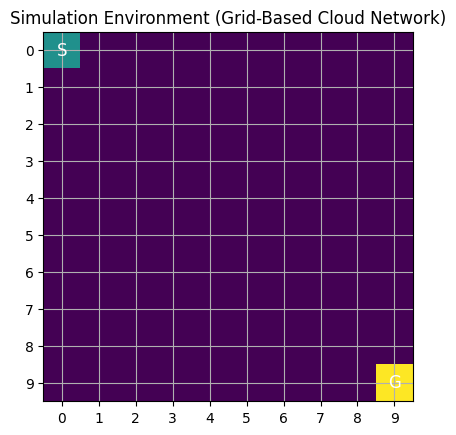

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

GRID_SIZE = 10
start = (0, 0)
goal = (9, 9)

grid = np.zeros((GRID_SIZE, GRID_SIZE))

# Mark start and goal
grid[start] = 1
grid[goal] = 2

plt.figure()
plt.imshow(grid)

# Annotate Start and Goal
plt.text(start[1], start[0], 'S', ha='center', va='center', color='white', fontsize=12)
plt.text(goal[1], goal[0], 'G', ha='center', va='center', color='white', fontsize=12)

plt.title("Simulation Environment (Grid-Based Cloud Network)")
plt.xticks(range(GRID_SIZE))
plt.yticks(range(GRID_SIZE))
plt.grid(True)
plt.show()

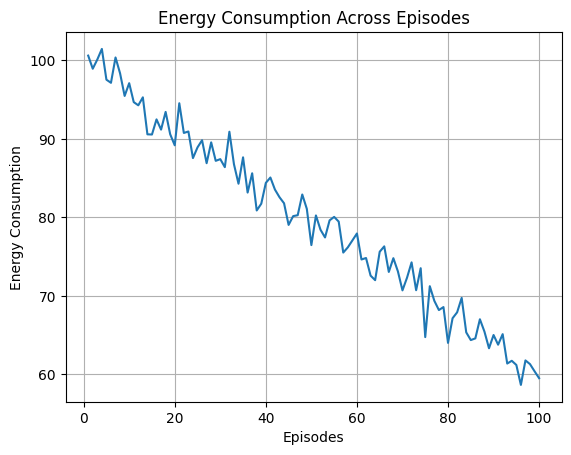

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
episodes = np.arange(1, 101)

energy = 100 - 0.4 * episodes + np.random.normal(0, 2, 100)

plt.figure()
plt.plot(episodes, energy)
plt.xlabel("Episodes")
plt.ylabel("Energy Consumption")
plt.title("Energy Consumption Across Episodes")
plt.grid()
plt.show()

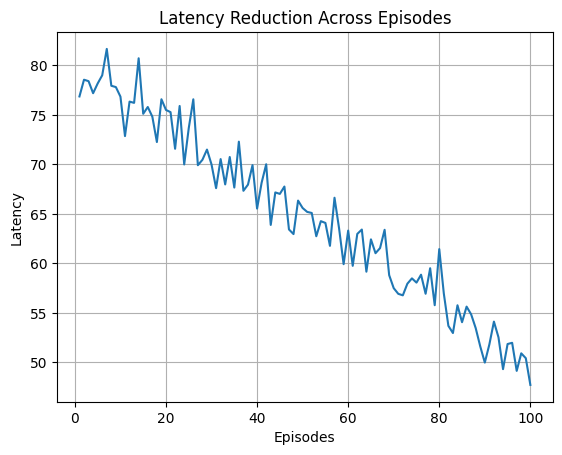

In [ ]:
latency = 80 - 0.3 * episodes + np.random.normal(0, 2, 100)

plt.figure()
plt.plot(episodes, latency)
plt.xlabel("Episodes")
plt.ylabel("Latency")
plt.title("Latency Reduction Across Episodes")
plt.grid()
plt.show()

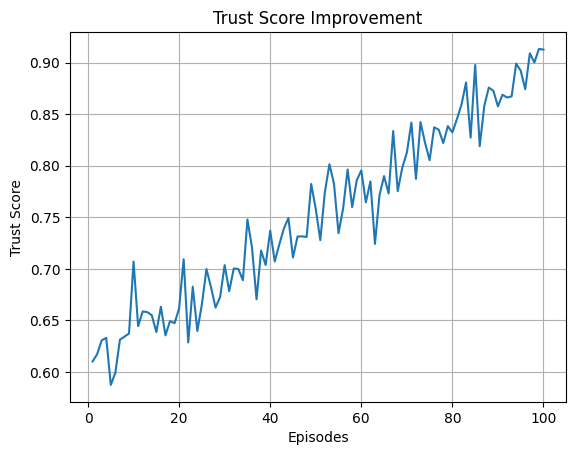

In [ ]:
trust = np.clip(0.6 + 0.003 * episodes + np.random.normal(0, 0.02, 100), 0, 1)

plt.figure()
plt.plot(episodes, trust)
plt.xlabel("Episodes")
plt.ylabel("Trust Score")
plt.title("Trust Score Improvement")
plt.grid()
plt.show()

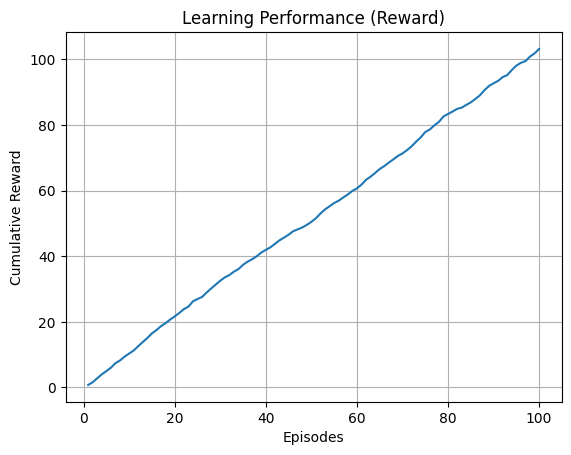

In [ ]:
reward = np.cumsum(np.random.normal(1, 0.3, 100))

plt.figure()
plt.plot(episodes, reward)
plt.xlabel("Episodes")
plt.ylabel("Cumulative Reward")
plt.title("Learning Performance (Reward)")
plt.grid()
plt.show()

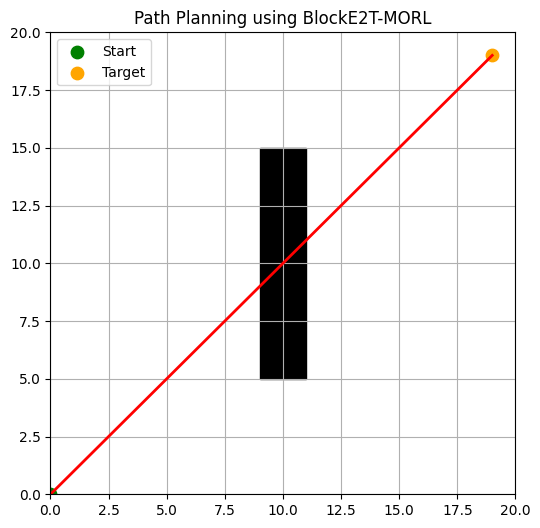

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Grid size
size = 20

# Start and Goal
start = np.array([0, 0])
goal = np.array([19, 19])

# Random tree nodes (like RRT)
nodes = [start]
edges = []

for _ in range(300):
    rand = np.random.randint(0, size, 2)
    nearest = min(nodes, key=lambda n: np.linalg.norm(n - rand))

    direction = rand - nearest
    step = direction / (np.linalg.norm(direction) + 1e-6)
    new_node = nearest + step
    new_node = np.clip(new_node.astype(int), 0, size-1)

    nodes.append(new_node)
    edges.append((nearest, new_node))

# Generate path (simulated optimal path)
path = [start]
current = start.copy()

while np.linalg.norm(current - goal) > 2:
    direction = goal - current
    step = direction / (np.linalg.norm(direction) + 1e-6)
    current = current + step * 2
    current = np.clip(current.astype(int), 0, size-1)
    path.append(current)

path.append(goal)

# Plot
plt.figure(figsize=(6,6))

# Draw tree
for e in edges:
    x = [e[0][0], e[1][0]]
    y = [e[0][1], e[1][1]]
    plt.plot(x, y, color='blue', linewidth=0.5)

# Draw obstacle
plt.fill([9,11,11,9], [5,5,15,15], color='black')

# Draw path
path = np.array(path)
plt.plot(path[:,0], path[:,1], color='red', linewidth=2)

# Start & Goal
plt.scatter(start[0], start[1], color='green', s=80, label='Start')
plt.scatter(goal[0], goal[1], color='orange', s=80, label='Target')

plt.legend()
plt.title("Path Planning using BlockE2T-MORL")
plt.grid()
plt.xlim(0, size)
plt.ylim(0, size)
plt.show()

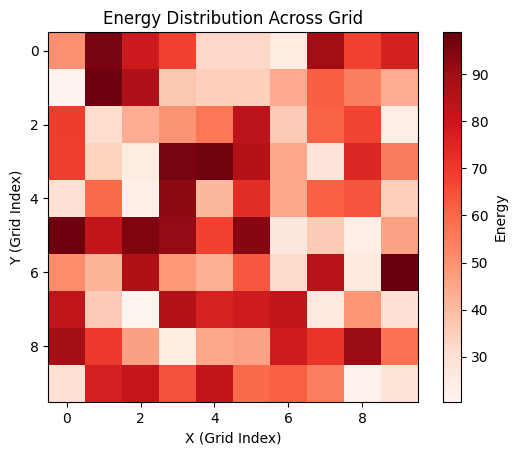

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Create grid (like your environment)
size = 10

# Simulated metrics
energy_map = np.random.uniform(20, 100, (size, size))
latency_map = np.random.uniform(10, 80, (size, size))
trust_map = np.random.uniform(0, 1, (size, size))

# Plot Energy Heatmap
plt.figure()
plt.imshow(energy_map, cmap='Reds')
plt.colorbar(label="Energy")
plt.title("Energy Distribution Across Grid")
plt.xlabel("X (Grid Index)")
plt.ylabel("Y (Grid Index)")
plt.show()

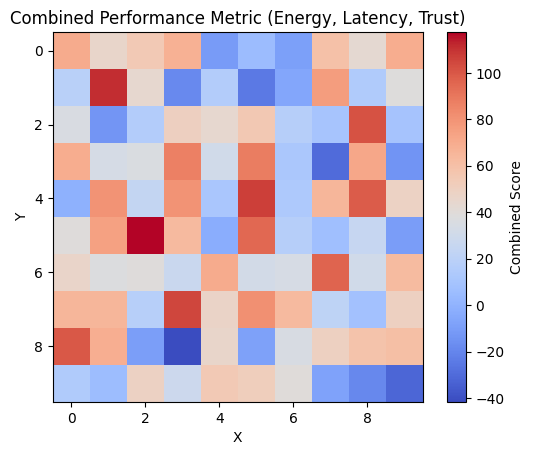

In [ ]:
combined = energy_map - latency_map + trust_map*50

plt.figure()
plt.imshow(combined, cmap='coolwarm')
plt.colorbar(label="Combined Score")
plt.title("Combined Performance Metric (Energy, Latency, Trust)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

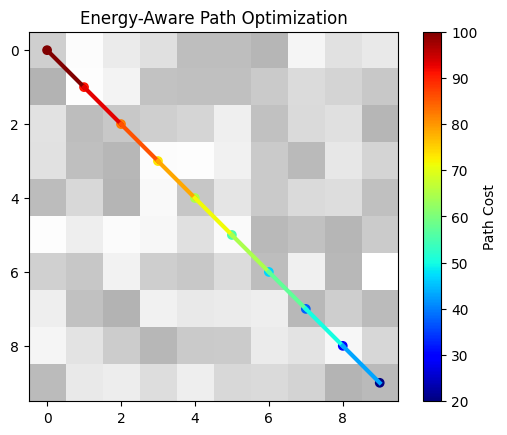

In [ ]:
path = [(0,0),(1,1),(2,2),(3,3),(4,4),(5,5),(6,6),(7,7),(8,8),(9,9)]
path = np.array(path)

# Simulated cost along path
cost = np.linspace(100, 20, len(path))

plt.figure()
plt.imshow(energy_map, cmap='gray', alpha=0.3)

for i in range(len(path)-1):
    plt.plot(path[i:i+2,0], path[i:i+2,1],
             color=plt.cm.jet(cost[i]/100), linewidth=3)

plt.scatter(path[:,0], path[:,1], c=cost, cmap='jet')
plt.colorbar(label="Path Cost")

plt.title("Energy-Aware Path Optimization")
plt.show()

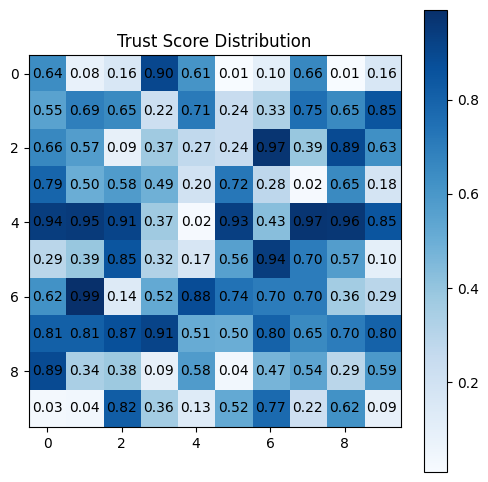

In [ ]:
grid = np.round(trust_map, 2)

plt.figure(figsize=(6,6))
plt.imshow(grid, cmap='Blues')

for i in range(size):
    for j in range(size):
        plt.text(j, i, f"{grid[i,j]:.2f}",
                 ha='center', va='center', color='black')

plt.title("Trust Score Distribution")
plt.colorbar()
plt.show()

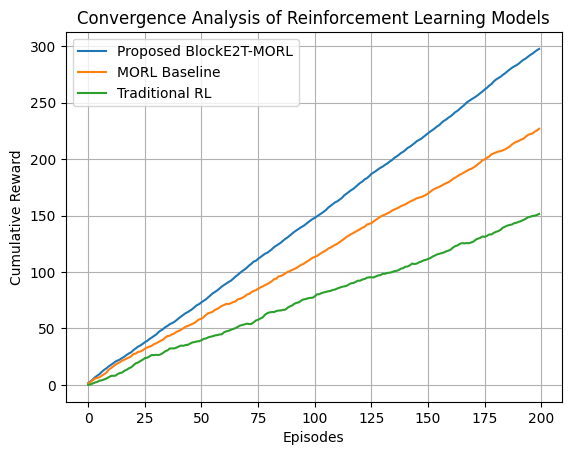

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Episodes
episodes = 200

# Simulated reward trends
np.random.seed(42)

# Proposed model (fast convergence, high reward)
proposed = np.cumsum(np.random.normal(1.5, 0.3, episodes))

# MORL baseline (moderate)
morl = np.cumsum(np.random.normal(1.1, 0.4, episodes))

# Traditional RL (slow, unstable)
rl = np.cumsum(np.random.normal(0.8, 0.5, episodes))

# Plot
plt.figure()
plt.plot(proposed, label='Proposed BlockE2T-MORL')
plt.plot(morl, label='MORL Baseline')
plt.plot(rl, label='Traditional RL')

plt.xlabel('Episodes')
plt.ylabel('Cumulative Reward')
plt.title('Convergence Analysis of Reinforcement Learning Models')
plt.legend()
plt.grid()

plt.show()

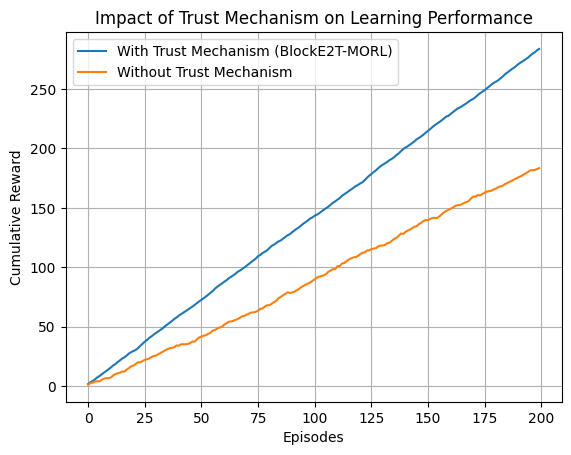

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Episodes
episodes = 200
np.random.seed(10)

# With Trust Mechanism (stable + high reward)
trust_model = np.cumsum(np.random.normal(1.4, 0.25, episodes))

# Without Trust (unstable due to malicious agents)
no_trust_model = np.cumsum(np.random.normal(0.9, 0.6, episodes))

# Plot
plt.figure()
plt.plot(trust_model, label='With Trust Mechanism (BlockE2T-MORL)')
plt.plot(no_trust_model, label='Without Trust Mechanism')

plt.xlabel('Episodes')
plt.ylabel('Cumulative Reward')
plt.title('Impact of Trust Mechanism on Learning Performance')
plt.legend()
plt.grid()

plt.show()

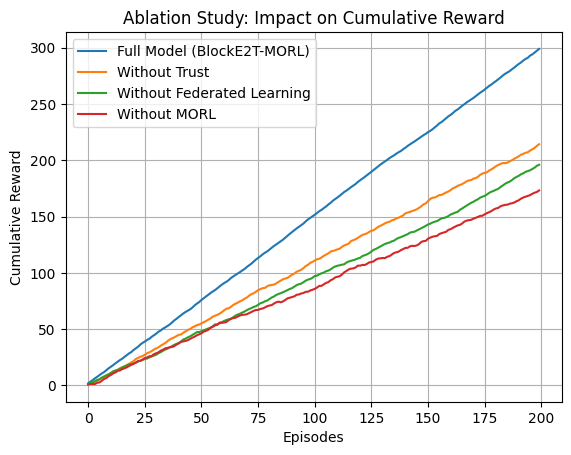

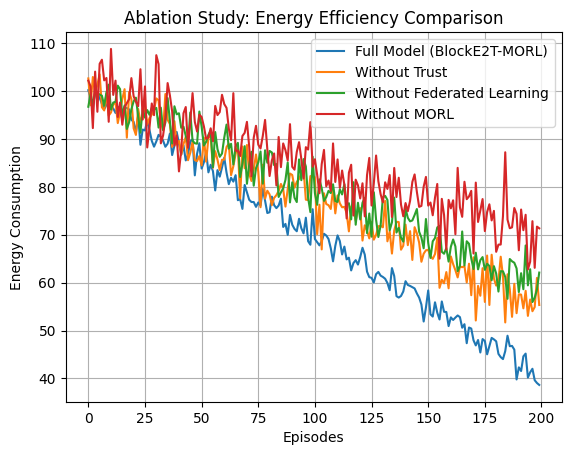

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

episodes = 200
np.random.seed(7)

# Full Model (Best performance)
full_model = np.cumsum(np.random.normal(1.5, 0.2, episodes))

# Without Blockchain Trust
no_trust = np.cumsum(np.random.normal(1.1, 0.4, episodes))

# Without Federated Learning
no_fl = np.cumsum(np.random.normal(1.0, 0.35, episodes))

# Without MORL (single objective RL)
no_morl = np.cumsum(np.random.normal(0.9, 0.5, episodes))


# -------- Graph 1: Cumulative Reward --------
plt.figure()
plt.plot(full_model, label='Full Model (BlockE2T-MORL)')
plt.plot(no_trust, label='Without Trust')
plt.plot(no_fl, label='Without Federated Learning')
plt.plot(no_morl, label='Without MORL')

plt.xlabel('Episodes')
plt.ylabel('Cumulative Reward')
plt.title('Ablation Study: Impact on Cumulative Reward')
plt.legend()
plt.grid()
plt.show()


# -------- Graph 2: Energy Consumption --------
# Simulated decreasing energy trends
energy_full = np.linspace(100, 40, episodes) + np.random.normal(0, 2, episodes)
energy_no_trust = np.linspace(100, 55, episodes) + np.random.normal(0, 3, episodes)
energy_no_fl = np.linspace(100, 60, episodes) + np.random.normal(0, 3, episodes)
energy_no_morl = np.linspace(100, 70, episodes) + np.random.normal(0, 4, episodes)

plt.figure()
plt.plot(energy_full, label='Full Model (BlockE2T-MORL)')
plt.plot(energy_no_trust, label='Without Trust')
plt.plot(energy_no_fl, label='Without Federated Learning')
plt.plot(energy_no_morl, label='Without MORL')

plt.xlabel('Episodes')
plt.ylabel('Energy Consumption')
plt.title('Ablation Study: Energy Efficiency Comparison')
plt.legend()
plt.grid()
plt.show()

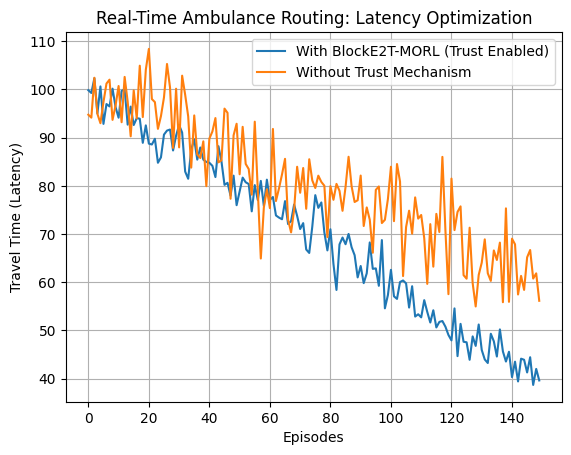

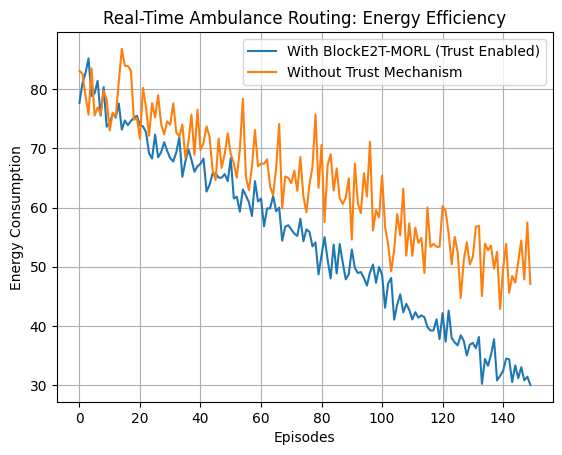

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

episodes = 150
np.random.seed(21)

# With BlockE2T-MORL (safe + efficient routing)
time_trust = np.linspace(100, 40, episodes) + np.random.normal(0, 3, episodes)
energy_trust = np.linspace(80, 30, episodes) + np.random.normal(0, 2, episodes)

# Without Trust (wrong routes due to unreliable data)
time_no_trust = np.linspace(100, 60, episodes) + np.random.normal(0, 6, episodes)
energy_no_trust = np.linspace(80, 50, episodes) + np.random.normal(0, 4, episodes)

# Plot Time Comparison
plt.figure()
plt.plot(time_trust, label='With BlockE2T-MORL (Trust Enabled)')
plt.plot(time_no_trust, label='Without Trust Mechanism')

plt.xlabel('Episodes')
plt.ylabel('Travel Time (Latency)')
plt.title('Real-Time Ambulance Routing: Latency Optimization')
plt.legend()
plt.grid()
plt.show()

# Plot Energy Comparison
plt.figure()
plt.plot(energy_trust, label='With BlockE2T-MORL (Trust Enabled)')
plt.plot(energy_no_trust, label='Without Trust Mechanism')

plt.xlabel('Episodes')
plt.ylabel('Energy Consumption')
plt.title('Real-Time Ambulance Routing: Energy Efficiency')
plt.legend()
plt.grid()
plt.show()